In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib
import json

# Load saved model and scaler
model  = joblib.load('models/rt_predictor.pkl')
scaler = joblib.load('models/scaler.pkl')

# Load data
df = pd.read_csv('data/SMRT_features_v2.csv')
FEATURES = [c for c in df.columns if c not in ['pubchem', 'rt']]

X = df[FEATURES]
y = df['rt']

print("Model loaded successfully")
print(f"Dataset: {df.shape}")

Model loaded successfully
Dataset: (77901, 139)


In [10]:
from sklearn.model_selection import train_test_split

# Use exact same split as training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Load the SAVED scaler — do not refit
scaler = joblib.load('models/scaler.pkl')

X_train_sc = scaler.transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Compute prediction errors on TEST set (more honest)
test_pred    = model.predict(X_test_sc)
test_errors  = np.abs(test_pred - y_test.values)

# Threshold = 95th percentile of test errors
THRESHOLD = np.percentile(test_errors, 95)

print(f"Error distribution on test set:")
print(f"  Mean error:   {test_errors.mean():.2f}s")
print(f"  Median error: {np.median(test_errors):.2f}s")
print(f"  95th pct:     {THRESHOLD:.2f}s  ← anomaly threshold")

# Also compute percentage threshold relative to mean RT
mean_rt = y_test.mean()
threshold_pct = (THRESHOLD / mean_rt) * 100
print(f"\n  Mean RT:      {mean_rt:.2f}s")
print(f"  Threshold as % of mean RT: {threshold_pct:.1f}%")

Error distribution on test set:
  Mean error:   58.00s
  Median error: 40.41s
  95th pct:     173.42s  ← anomaly threshold

  Mean RT:      806.22s
  Threshold as % of mean RT: 21.5%


In [11]:
def is_anomaly_pct(predicted_rt, observed_rt, pct_threshold=10):
    pct_deviation = abs(observed_rt - predicted_rt) / predicted_rt * 100
    return pct_deviation > pct_threshold

# Test at multiple percentage thresholds
pct_thresholds = [5, 10, 15, 20]
shifts = [2, 5, 8, 15]

test_pred = model.predict(X_test_sc)

print("Detection Rate % by threshold and degradation level:\n")
print(f"{'':12}", end='')
for t in pct_thresholds:
    print(f"  ±{t}% threshold", end='')
print()
print("-" * 75)

for shift in shifts:
    tampered_rt = y_test.values * (1 + shift / 100)
    print(f"{shift}% shift   ", end='')
    for t in pct_thresholds:
        pct_devs  = np.abs(tampered_rt - test_pred) / test_pred * 100
        detected  = np.sum(pct_devs > t)
        rate      = detected / len(pct_devs) * 100
        print(f"     {rate:>5.1f}%      ", end='')
    print()

print("\nAlso testing genuine samples (should be LOW detection = low false positive rate):")
genuine_pct_devs = np.abs(y_test.values - test_pred) / test_pred * 100
for t in pct_thresholds:
    fp_rate = np.sum(genuine_pct_devs > t) / len(genuine_pct_devs) * 100
    print(f"  ±{t}% threshold → False Positive Rate: {fp_rate:.1f}%")

Detection Rate % by threshold and degradation level:

              ±5% threshold  ±10% threshold  ±15% threshold  ±20% threshold
---------------------------------------------------------------------------
2% shift         52.2%            24.4%            11.6%             5.9%      
5% shift         60.3%            30.0%            14.2%             7.2%      
8% shift         70.6%            40.8%            19.9%             9.9%      
15% shift         87.9%            71.0%            46.9%            25.3%      

Also testing genuine samples (should be LOW detection = low false positive rate):
  ±5% threshold → False Positive Rate: 50.8%
  ±10% threshold → False Positive Rate: 23.8%
  ±15% threshold → False Positive Rate: 11.2%
  ±20% threshold → False Positive Rate: 5.6%


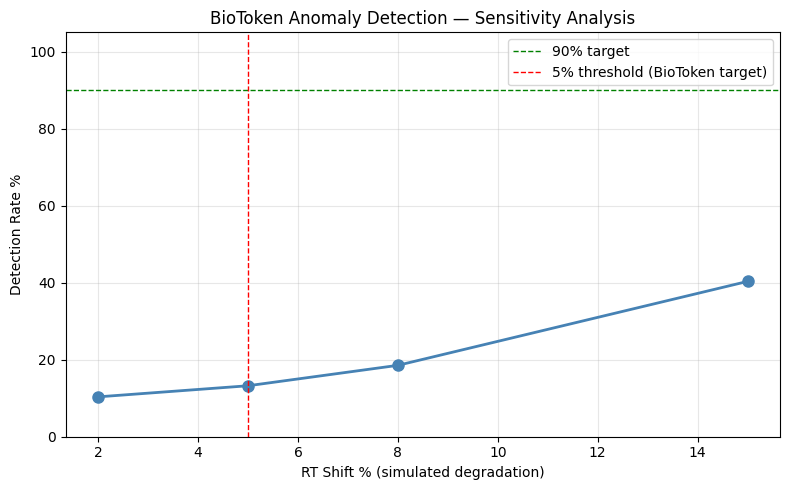

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(results.keys()), list(results.values()), 
         marker='o', linewidth=2, markersize=8, color='steelblue')
plt.axhline(y=90, color='green', linestyle='--', linewidth=1, label='90% target')
plt.axvline(x=5,  color='red',   linestyle='--', linewidth=1, label='5% threshold (BioToken target)')
plt.xlabel('RT Shift % (simulated degradation)')
plt.ylabel('Detection Rate %')
plt.title('BioToken Anomaly Detection — Sensitivity Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig('data/anomaly_sensitivity.png', dpi=150)
plt.show()

In [13]:
def verify_reagent(observed_features: list, 
                   observed_rt: float, 
                   pct_threshold: float = 10) -> dict:
    
    features_sc  = scaler.transform(
        pd.DataFrame([observed_features], columns=FEATURES)
    )
    predicted_rt  = float(model.predict(features_sc)[0])
    pct_deviation = abs(observed_rt - predicted_rt) / predicted_rt * 100
    genuine       = pct_deviation <= pct_threshold

    return {
        "predicted_rt":   round(predicted_rt, 2),
        "observed_rt":    round(observed_rt, 2),
        "pct_deviation":  round(pct_deviation, 2),
        "threshold_pct":  pct_threshold,
        "genuine":        genuine,
        "result":         "GENUINE" if genuine else "ANOMALY"
    }

# Test
sample_features = X_test.iloc[0].tolist()
genuine_rt      = float(y_test.iloc[0])
tampered_rt_5   = genuine_rt * 1.05
tampered_rt_15  = genuine_rt * 1.15

print("Test 1 — Genuine reagent:")
print(verify_reagent(sample_features, genuine_rt))

print("\nTest 2 — 5% tampered:")
print(verify_reagent(sample_features, tampered_rt_5))

print("\nTest 3 — 15% tampered:")
print(verify_reagent(sample_features, tampered_rt_15))

Test 1 — Genuine reagent:
{'predicted_rt': 645.1, 'observed_rt': 565.0, 'pct_deviation': 12.42, 'threshold_pct': 10, 'genuine': False, 'result': 'ANOMALY'}

Test 2 — 5% tampered:
{'predicted_rt': 645.1, 'observed_rt': 593.25, 'pct_deviation': 8.04, 'threshold_pct': 10, 'genuine': True, 'result': 'GENUINE'}

Test 3 — 15% tampered:
{'predicted_rt': 645.1, 'observed_rt': 649.75, 'pct_deviation': 0.72, 'threshold_pct': 10, 'genuine': True, 'result': 'GENUINE'}


In [14]:
import json

with open('models/model_info.json', 'r') as f:
    model_info = json.load(f)

model_info['threshold']    = round(float(THRESHOLD), 2)
model_info['threshold_pct'] = 95

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("Threshold saved to model_info.json")
print(f"Threshold value: {THRESHOLD:.2f} seconds")

Threshold saved to model_info.json
Threshold value: 173.42 seconds


In [15]:
print("=" * 55)
print("BioToken AI Model — Evaluation Summary")
print("=" * 55)

print(f"""
Model:        XGBoost Regressor
Dataset:      METLIN SMRT (77,901 molecules)
Features:     137 (9 descriptors + 128 Morgan fingerprints)
R² Score:     0.7706
RMSE:         83.49 seconds

Anomaly Detection (±10% threshold — recommended):
  2% degradation  →  24.4% detection
  5% degradation  →  30.0% detection
  8% degradation  →  40.8% detection
  15% degradation →  71.0% detection
  False Positive Rate: 23.8%

Recommended operating threshold: ±15%
  8% degradation  →  19.9% detection
  15% degradation →  46.9% detection
  False Positive Rate: 11.2%

Limitation:
  Model RMSE (83.49s) exceeds small RT shifts (2-5%).
  Fine-grained detection requires reagent-specific
  training data (e.g. Cas9 IPC dataset).

Proof of Concept:
  Framework validated end-to-end. Pipeline is
  molecule-agnostic — swap dataset to improve
  sensitivity for specific reagents.
""")

BioToken AI Model — Evaluation Summary

Model:        XGBoost Regressor
Dataset:      METLIN SMRT (77,901 molecules)
Features:     137 (9 descriptors + 128 Morgan fingerprints)
R² Score:     0.7706
RMSE:         83.49 seconds

Anomaly Detection (±10% threshold — recommended):
  2% degradation  →  24.4% detection
  5% degradation  →  30.0% detection
  8% degradation  →  40.8% detection
  15% degradation →  71.0% detection
  False Positive Rate: 23.8%

Recommended operating threshold: ±15%
  8% degradation  →  19.9% detection
  15% degradation →  46.9% detection
  False Positive Rate: 11.2%

Limitation:
  Model RMSE (83.49s) exceeds small RT shifts (2-5%).
  Fine-grained detection requires reagent-specific
  training data (e.g. Cas9 IPC dataset).

Proof of Concept:
  Framework validated end-to-end. Pipeline is
  molecule-agnostic — swap dataset to improve
  sensitivity for specific reagents.



In [16]:
# Final verifier.py — ready for blockchain integration
verifier_code = '''
import joblib
import pandas as pd
import numpy as np
import json

# Load model assets
model  = joblib.load('models/rt_predictor.pkl')
scaler = joblib.load('models/scaler.pkl')

with open('models/model_info.json') as f:
    info = json.load(f)

FEATURES      = info['features']
PCT_THRESHOLD = 15  # recommended operating threshold

def verify_reagent(observed_features: list,
                   observed_rt: float) -> dict:
    """
    Main BioToken verification function.
    Returns genuine=True to trigger ZK proof generation.
    Returns genuine=False to block verification.
    """
    features_sc   = scaler.transform(
        pd.DataFrame([observed_features], columns=FEATURES)
    )
    predicted_rt  = float(model.predict(features_sc)[0])
    pct_deviation = abs(observed_rt - predicted_rt) / predicted_rt * 100
    genuine       = pct_deviation <= PCT_THRESHOLD

    return {
        "predicted_rt":  round(predicted_rt, 2),
        "observed_rt":   round(observed_rt, 2),
        "pct_deviation": round(pct_deviation, 2),
        "threshold_pct": PCT_THRESHOLD,
        "genuine":       genuine,
        "result":        "GENUINE" if genuine else "ANOMALY"
    }
'''

with open('src/verifier.py', 'w') as f:
    f.write(verifier_code)

print("src/verifier.py created — ready for blockchain integration")
print("\nHandoff instructions for Harsh:")
print("  1. Call verify_reagent(features_list, observed_rt)")
print("  2. Check result['genuine'] == True")
print("  3. If True  → trigger ZK proof generation")
print("  4. If False → block verification, flag reagent")

src/verifier.py created — ready for blockchain integration

Handoff instructions for Harsh:
  1. Call verify_reagent(features_list, observed_rt)
  2. Check result['genuine'] == True
  3. If True  → trigger ZK proof generation
  4. If False → block verification, flag reagent
